In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import bayesflow as bf

from bayesflow.simulation import Prior, Simulator, GenerativeModel

np.set_printoptions(suppress=True)

# Posterior Estimation for Simple Autoregressive Model

In this notebook, we do posterior estimates for the Ricker model, defined as follows:


\begin{align}
    x_t &\sim \textrm{Poisson}(\rho N_t), \\
    \xi_t &\sim \mathcal{N}(0, \sigma^2), \\
    N_{t+1} &= r N_t \exp{(-N_t + \xi_t)}.
\end{align}


The priors are sampled as follows:


\begin{align}
    r &\sim \mathcal{U}(1, 10), \\
    \rho &\sim \mathcal{U}(0, 10), \\
    \sigma &\sim \mathcal{U}(0.01, 1)
\end{align}


## Priors

In [79]:
def prior_fun(rng=None):

    if rng is None:
        rng = np.random.default_rng()

    r = rng.uniform(1., 10.)
    rho = rng.uniform(0., 10.)
    sigma = rng.uniform(0.01, 1)

    theta = np.array([r, rho, sigma])
    return theta


In [90]:
param_names = [r'$r$', r'$\rho$', r'$\sigma$']

In [92]:
prior = Prior(prior_fun=prior_fun, param_names=param_names)

## Simulator

In [80]:
def simulator_fun(theta, n_timesteps=101, rng=None):

    if rng is None:
        rng = np.random.default_rng()
    
    r, rho, sigma = theta

    # Expected population
    N = 10

    # Estimated population
    x = np.zeros((n_timesteps, 1))

    for t in range(n_timesteps):
        x[t,:] = rng.poisson(rho * N)
        xi = rng.normal(0, sigma)
        N = r * N * np.exp(-N + xi)
    
    return x

In [93]:
simulator = Simulator(simulator_fun=simulator_fun)

## Generative Model

In [81]:
def model_fun():

    theta = prior_fun()
    x = simulator_fun(theta)

    return theta, x

<Axes: >

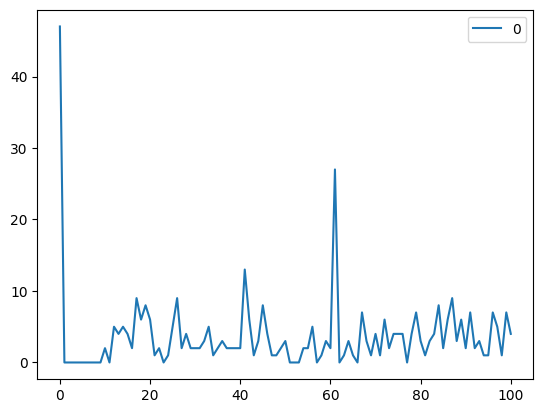

In [88]:
theta, x = model_fun()
sns.lineplot(x)

In [89]:
theta

array([1.9369432 , 4.86205111, 0.5430514 ])

In [94]:
model = GenerativeModel(prior=prior_fun, simulator=simulator_fun, simulator_is_batched=False)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 3)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 101, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


## Prior Predictive Check

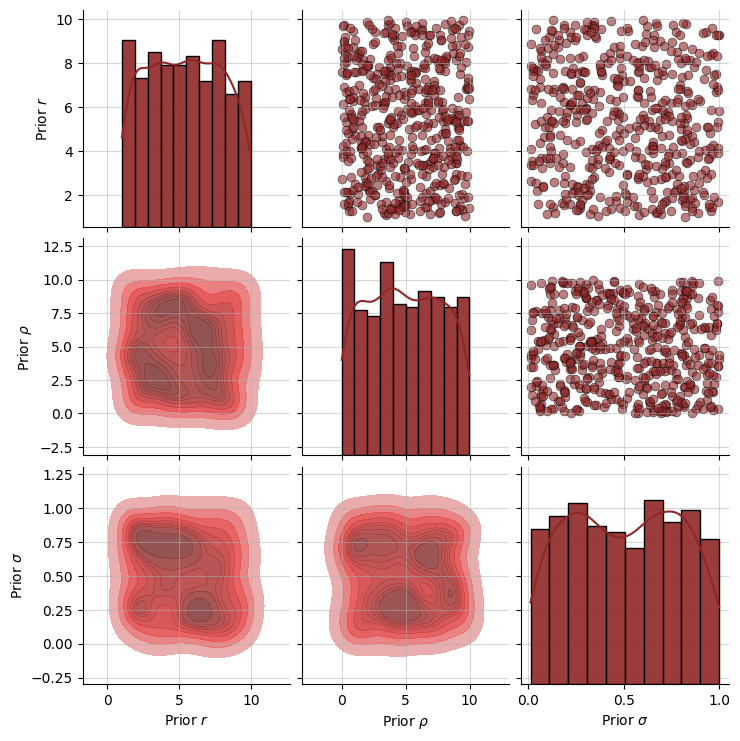

In [95]:
f = prior.plot_prior2d(n_samples=500)

In [96]:
sim = model(50)
sim

{'prior_non_batchable_context': None,
 'prior_batchable_context': None,
 'prior_draws': array([[5.43935386, 5.94785114, 0.27116532],
        [7.71043377, 9.38766088, 0.7169354 ],
        [9.48770807, 5.04452221, 0.03114358],
        [8.09601545, 6.50622598, 0.78924932],
        [7.89551735, 8.78252254, 0.70538287],
        [8.24042825, 0.20718179, 0.87578287],
        [3.76535151, 5.4351805 , 0.10848607],
        [9.31152577, 4.56612403, 0.49884151],
        [6.08401177, 9.60530383, 0.88930137],
        [4.01553096, 4.37178079, 0.42175891],
        [5.6219913 , 3.26849353, 0.38012406],
        [7.91757454, 2.7414457 , 0.60126101],
        [2.44418904, 1.8568659 , 0.88483341],
        [6.65876584, 2.93353991, 0.57104353],
        [7.43453179, 0.50749526, 0.3509095 ],
        [6.90504368, 1.32758284, 0.78267405],
        [8.73138284, 2.19785184, 0.50963209],
        [8.12899646, 5.83153196, 0.76427946],
        [6.74751108, 7.31536584, 0.02122774],
        [2.69302722, 3.56807302, 0.2672

## Data preprocessing

In [101]:
def configurator(input_dict):

    output_dict = {}

    # Prior draws are the parameters to estimate
    output_dict['parameters'] = input_dict['prior_draws']

    # Time embedding
    batch_size, n_timesteps, _ = input_dict['sim_data'].shape
    t = np.linspace(0., 1., n_timesteps)
    t_batched = np.tile(t[np.newaxis, :, np.newaxis], (batch_size, 1, 1))

    output_dict['summary_conditions'] = np.concatenate((input_dict['sim_data'], t_batched), axis=-1)

    return output_dict

In [103]:
sim = model(1000)
x = configurator(sim)['summary_conditions']
x.shape

(1000, 101, 2)

In [104]:
x[0,:,1]

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

## Neural Approximator

In [119]:
# Time Series Transformer as summary network
summary_network = bf.networks.TimeSeriesTransformer(input_dim=2, summary_dim=5)

In [116]:
inference_network = bf.networks.InvertibleNetwork(
    num_params=3,
    num_coupling_layers=6, 
    coupling_settings={
        'kernel_regularizer': tf.keras.regularizers.l2(1e-4),
        'dropout_prob': 0.2
    }
)

In [120]:
amortizer = bf.amortizers.AmortizedPosterior(inference_network, summary_network)

## Training

In [121]:
trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=model,
    configurator=configurator
)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [122]:
history = trainer.train_offline(sim, epochs=20, batch_size=32, validation_sims=model(100))

Training epoch 1: 100%|██████████| 32/32 [01:15<00:00,  2.37s/it, Epoch: 1, Batch: 32,Loss: 4.323,W.Decay: 0.325,Avg.Loss: 10.693,Avg.W.Decay: 0.333,LR: 4.97E-04]
INFO:root:Validation, Epoch: 1, Loss: 4.932
Training epoch 2: 100%|██████████| 32/32 [00:02<00:00, 11.12it/s, Epoch: 2, Batch: 32,Loss: 4.496,W.Decay: 0.307,Avg.Loss: 4.653,Avg.W.Decay: 0.315,LR: 4.88E-04]
INFO:root:Validation, Epoch: 2, Loss: 4.486
Training epoch 3: 100%|██████████| 32/32 [00:02<00:00, 11.28it/s, Epoch: 3, Batch: 32,Loss: 3.366,W.Decay: 0.294,Avg.Loss: 3.922,Avg.W.Decay: 0.300,LR: 4.73E-04]
INFO:root:Validation, Epoch: 3, Loss: 4.046
Training epoch 4: 100%|██████████| 32/32 [00:02<00:00, 10.92it/s, Epoch: 4, Batch: 32,Loss: 3.625,W.Decay: 0.288,Avg.Loss: 3.482,Avg.W.Decay: 0.291,LR: 4.53E-04]
INFO:root:Validation, Epoch: 4, Loss: 3.460
Training epoch 5: 100%|██████████| 32/32 [00:02<00:00, 11.15it/s, Epoch: 5, Batch: 32,Loss: 2.835,W.Decay: 0.284,Avg.Loss: 3.163,Avg.W.Decay: 0.286,LR: 4.28E-04]
INFO:root:Val

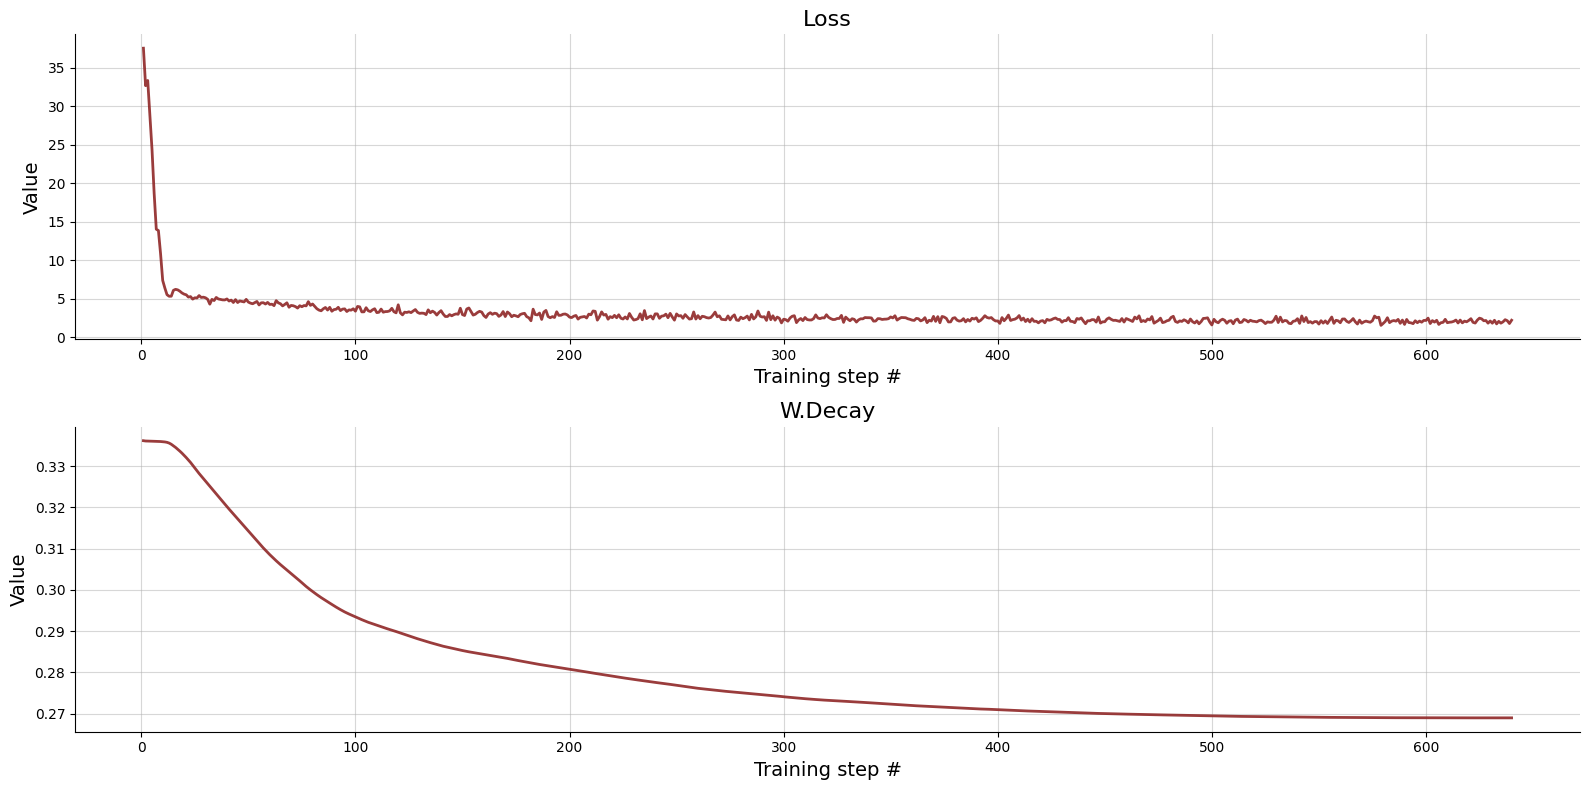

In [125]:
f = bf.diagnostics.plot_losses(history['train_losses'])

## Validation

In [127]:
## Resimulation
resim = model(200)

## Configuring the resimulation
out = configurator(resim)

In [139]:
## Super extra speedy posterior sampling with the amortizer!
posterior_samples = amortizer.sample(out, n_samples=500)
posterior_samples[0]

array([[ 3.180816  ,  3.2022674 ,  0.5634503 ],
       [ 8.208404  ,  1.5286131 ,  0.70858353],
       [ 7.780625  ,  1.0750489 ,  0.5941239 ],
       ...,
       [ 5.52018   ,  1.5337908 ,  0.48761597],
       [ 2.1737032 ,  5.089552  ,  1.17043   ],
       [10.258106  ,  1.2964007 ,  0.78842235]], dtype=float32)

### Posterior Predictive Check

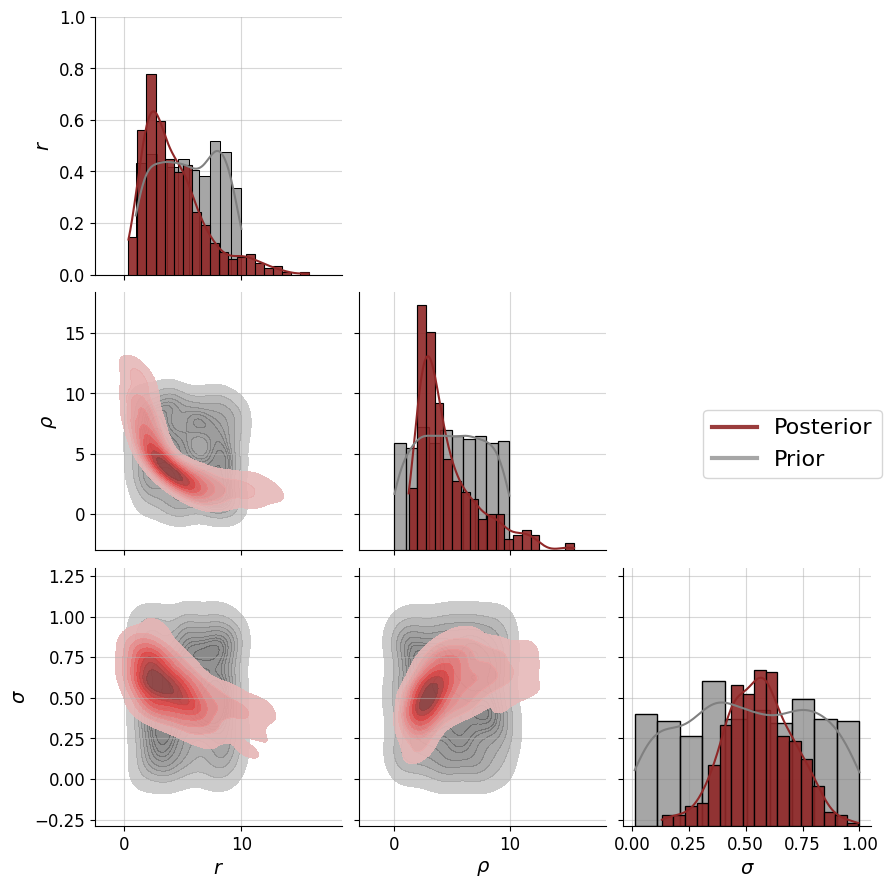

In [140]:
draws = posterior_samples[-1]
f = bf.diagnostics.plot_posterior_2d(
    posterior_draws=draws,
    prior=trainer.generative_model.prior,
    param_names=param_names
)

### Parameter Recovery

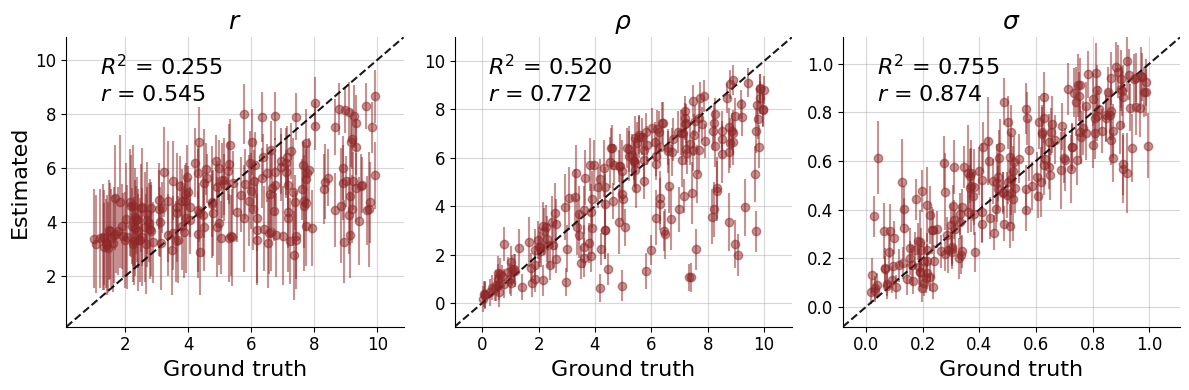

In [141]:
f = bf.diagnostics.plot_recovery(
    posterior_samples,
    out['parameters'],
    param_names=param_names
)

### Simulation-Based Calibration

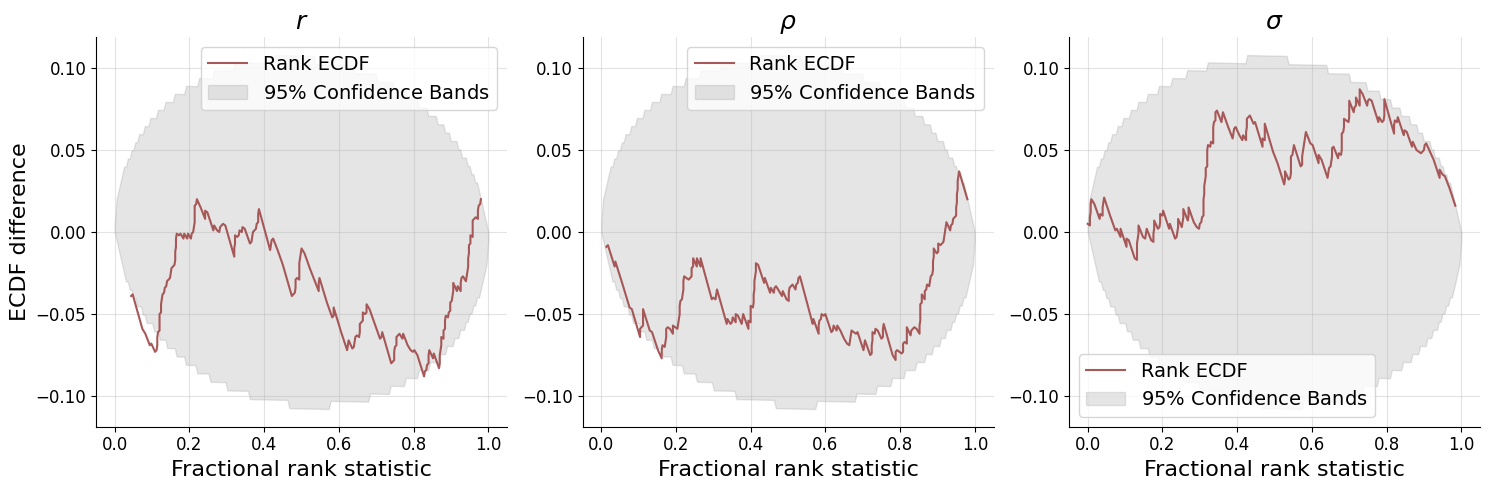

In [142]:
f = bf.diagnostics.plot_sbc_ecdf(
    posterior_samples,
    out['parameters'],
    difference=True,
    param_names=param_names
)